In [1]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
colors_blais = ['#33658A','#86BBD8']

In [3]:
def gaussian_pulse(x, mu, sig):
    gg = np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))
    gg *= np.pi/np.sum(gg)/dt
    return gg

def gaussian_pulse_zeroends(tt, sigma, theta):
    gg = gaussian_pulse(tt, tt[-1]/2, sigma)
    gg -= gg[0]
    gg /= np.max(gg)
    return gg

def pretty_circ_plot(circ, res=10, figsize=(20,1), qubit='0', init='|0\rangle'):
    plt.figure(figsize=figsize, dpi=200)
    
    i = 0
    for gate, num_gates in circ:
        N = num_gates*res
        NN = np.arange(i,i+N)
        if gate=='I':
            plt.plot(NN, [0.]*N, color='k', lw=2)
        elif gate=='X':
            gg_X = gaussian_pulse_zeroends(np.arange(N), N/2, N/4)
            plt.plot(NN, gg_X, color=colors[0], lw=2)
            plt.fill_between(NN,0,gg_X, alpha=0.5, color=colors[0])
        i += N
    plt.ylim(-0.05, 1.05)
    plt.text(0, 0.5, r'qubit $%s: %s$'%(qubit, init), size=20)
    plt.axis('off')
    plt.show()

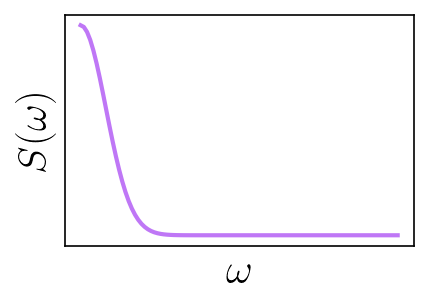

In [4]:
xx = np.linspace(0,np.pi,100)
dt = 1
gg = gaussian_pulse(xx, mu=0, sig=.25)
plt.figure(dpi=150, figsize=(3,2))
plt.plot(gg, lw=2, color=colors_greg[1])
plt.ylabel('$S(\omega)$', size=20)
plt.xlabel('$\omega$', size=20)
plt.xticks([])
plt.yticks([])
plt.show()

# Hamiltonian for system (TLS,Q0,Q1)

<font size="4">
    Notation: TLS - Q0 - Q1 (where Q0 is the main qubit) <br><br>
    $$ H(t) = \big(\beta_0 IZI + \Omega_0 IXI + \beta_1 IIZ + \xi XZI + J IZZ \big)/2 $$ <br>
    where all qubits are initialized in $|0\rangle$

# Simulate 3Q using qutip

In [6]:
import qutip as qt
from qutip import sigmaz, sigmax, sigmay, identity, tensor
from qutip.solver import Options

IZI = tensor(identity(2),sigmaz(),identity(2))
IIZ = tensor(identity(2),identity(2),sigmaz())
XZI = tensor(sigmax(),sigmaz(),identity(2))
IZZ = tensor(identity(2),sigmaz(),sigmaz())
IXI = tensor(identity(2),sigmax(),identity(2))
IIX = tensor(identity(2),identity(2),sigmax())
IIY = tensor(identity(2),identity(2),sigmay())
IYI = tensor(identity(2),sigmay(),identity(2))

In [7]:
def get_H(beta1,beta2,xi,J,omega=0):
    H = 1/8*(beta1*IZI + # Q1 detuning
             beta2*IIZ + # Q2 detuning
             xi *  XZI + # Q1-TLS coupling
             J  *  IZZ + # Q1-Q2 coupling 
             omega*IXI ) # Q1 control
    return H

In [8]:
psi_0 = qt.states.basis(2,0)
psi_1 = qt.states.basis(2,1)
psi_p = (psi_0+psi_1)/np.sqrt(2)

psi_000 = tensor(psi_0, psi_0, psi_0)
psi_0p0 = tensor(psi_0, psi_p, psi_0)
psi_010 = tensor(psi_0, psi_1, psi_0)

rho_000 = qt.ket2dm(psi_000)
rho_0p0 = qt.ket2dm(psi_0p0)
rho_010 = qt.ket2dm(psi_010)

a_op = 0.5*(sigmax()+1j*sigmay())
adag_op = 0.5*(sigmax()-1j*sigmay())
# adag_op*psi_0 == psi_1
# a_op*psi_1 == psi_0
IaI = tensor(identity(2),a_op,identity(2))

In [9]:
def get_H_DD(t):
    if t%2<1:
        return 1/8*np.pi*tensor(identity(2),identity(2),sigmax())
    elif t%2>1:
        return 1/8*np.pi*tensor(identity(2),identity(2),sigmay())

def DD_Xcoeff(t, args):
    if t%dt==0:
        return 0
    if t%(2*dt)<dt:
        return 1
    return 0
    
def DD_Ycoeff(t, args):
    if t%dt==0:
        return 0
    return 1-DD_Xcoeff(t,args)

In [10]:
dt = 0.03555
beta1 = 4
beta2 = 2
J = 1
xi = 0.0
gamma = 0.1
lmbda = 0.01

rho0 = rho_0p0

t_steps = 1000
# tt_fine = np.linspace(0,t_steps*dt,10*t_steps)
# tt = tt_fine[::40]
tt = np.arange(0,t_steps,4)*dt

# Finding Experimental Parameters

In [11]:
def DD_Xcoeff(t, args):
    if t%(2*dt)<dt:
        return 1
    return 0
    
def DD_Ycoeff(t, args):
    if t%(2*dt)>dt:
        return 1
    return 0

def H_DM(beta1,beta2,xi,J,omega): return [get_H(beta1,beta2,xi,J,0), 
                                           [omega/2*IXI,DD_Xcoeff],
                                           [omega/2*IYI,DD_Ycoeff]]
def H_DS(beta1,beta2,xi,J,omega): return [get_H(beta1,beta2,xi,J,0), 
                                           [omega/2*IIX,DD_Xcoeff],
                                           [omega/2*IIY,DD_Ycoeff]]
def H_FE(beta1,beta2,xi,J,omega): return get_H(beta1,beta2,xi,J,0)

In [12]:
def gaussian_pulse_zeroends(tt, sigma, theta):
    gg = gaussian_pulse(tt, tt[-1]/2, sigma)
    gg -= gg[0]
    gg *= np.pi/np.sum(gg)/dt
    return gg

dt = 0.03555
tt_pulse = np.linspace(0,dt,128)
pulse = gaussian_pulse_zeroends(tt_pulse, dt/4, np.pi)

def get_gaussian_pulse(t): return (np.exp(-(t-dt/2)**2/(dt/4))-np.exp(-(dt/2)**2/(dt/4)))*np.pi/0.023198518270807957/3.117170188087497

def DD_gXcoeff(t, args):
    if t%(2*dt)<dt:
        return get_gaussian_pulse(t%dt)
    return 0
    
def DD_gYcoeff(t, args):
    if t%(2*dt)>dt:
        return get_gaussian_pulse(t%dt)
    return 0

def H_gDM(beta1,beta2,xi,J,omega): return [get_H(beta1,beta2,xi,J,0), 
                                           [omega/2*IXI,DD_gXcoeff],
                                           [omega/2*IYI,DD_gYcoeff]]
def H_gDS(beta1,beta2,xi,J,omega): return [get_H(beta1,beta2,xi,J,0), 
                                           [omega/2*IIX,DD_gXcoeff],
                                           [omega/2*IIY,DD_gYcoeff]]

In [15]:
tt_exp = np.linspace(0,30*80,30)*dt

ps_exp = {'FE0': np.array([0.991 , 0.9913, 0.993 , 0.9929, 0.992 , 0.9932, 0.9931, 0.9914,
        0.9924, 0.992 , 0.9927, 0.9906, 0.9919, 0.992 , 0.9941, 0.9915,
        0.9912, 0.9913, 0.9913, 0.9914, 0.9905, 0.9927, 0.9903, 0.9917,
        0.9884, 0.9924, 0.9913, 0.9901, 0.9893, 0.9911]),
 'FE1': np.array([0.9907, 0.9756, 0.9614, 0.9476, 0.9373, 0.9201, 0.9083, 0.8953,
        0.8804, 0.8728, 0.8603, 0.8498, 0.8326, 0.8238, 0.8148, 0.8113,
        0.7957, 0.784 , 0.778 , 0.766 , 0.7535, 0.738 , 0.7366, 0.7274,
        0.7136, 0.7108, 0.696 , 0.6951, 0.6809, 0.6724]),
 'FE+': np.array([0.9919, 0.9395, 0.7968, 0.6014, 0.3807, 0.2127, 0.1   , 0.0552,
        0.1111, 0.2418, 0.4205, 0.6057, 0.7524, 0.8431, 0.864 , 0.8107,
        0.6988, 0.5574, 0.4187, 0.3035, 0.237 , 0.2367, 0.2732, 0.3554,
        0.4613, 0.5577, 0.6272, 0.6762, 0.6671, 0.6394]),
 'DM0': np.array([0.9923, 0.9817, 0.977 , 0.9668, 0.9607, 0.9502, 0.9447, 0.9387,
        0.9322, 0.9201, 0.9156, 0.9102, 0.9077, 0.8954, 0.8956, 0.8893,
        0.8793, 0.8774, 0.8689, 0.8634, 0.8539, 0.8511, 0.8492, 0.8424,
        0.8353, 0.8354, 0.8302, 0.8239, 0.8251, 0.8209]),
 'DM1': np.array([0.99  , 0.9855, 0.9775, 0.9687, 0.9598, 0.9512, 0.949 , 0.9387,
        0.9295, 0.9252, 0.9165, 0.9082, 0.9023, 0.892 , 0.8858, 0.8832,
        0.8763, 0.8722, 0.8647, 0.8566, 0.8551, 0.8454, 0.8477, 0.8413,
        0.8374, 0.8325, 0.8263, 0.819 , 0.8199, 0.8143]),
 'DM+': np.array([0.9917, 0.9786, 0.9431, 0.8953, 0.8323, 0.7637, 0.6846, 0.5936,
        0.5207, 0.4394, 0.3688, 0.2926, 0.2388, 0.1964, 0.182 , 0.1582,
        0.1647, 0.1817, 0.2064, 0.2488, 0.284 , 0.336 , 0.3771, 0.4306,
        0.4875, 0.53  , 0.572 , 0.6006, 0.6423, 0.6585]),
 'DS0': np.array([0.991 , 0.9924, 0.9927, 0.9936, 0.9904, 0.9928, 0.9905, 0.9918,
        0.9931, 0.9926, 0.9926, 0.9918, 0.9912, 0.9907, 0.9917, 0.9924,
        0.9913, 0.9913, 0.9901, 0.9916, 0.9914, 0.9889, 0.9907, 0.992 ,
        0.9904, 0.9907, 0.9905, 0.991 , 0.9908, 0.9914]),
 'DS1': np.array([0.9928, 0.9733, 0.9605, 0.947 , 0.9364, 0.9204, 0.9044, 0.8895,
        0.8815, 0.8661, 0.8608, 0.8481, 0.8381, 0.8285, 0.8146, 0.8096,
        0.7974, 0.7889, 0.7721, 0.7692, 0.7548, 0.7577, 0.7284, 0.7263,
        0.7143, 0.7112, 0.7063, 0.6978, 0.685 , 0.6752]),
 'DS+': np.array([0.9916, 0.9015, 0.7173, 0.5406, 0.4861, 0.5863, 0.7557, 0.8881,
        0.8995, 0.7679, 0.5752, 0.4336, 0.4186, 0.5308, 0.6853, 0.7722,
        0.7267, 0.5792, 0.3986, 0.2972, 0.3246, 0.4534, 0.5748, 0.6272,
        0.5562, 0.3987, 0.2567, 0.1991, 0.2569, 0.4   ])}

# Cairo
# ps_exp = {0: {'FE0': array([0.991 , 0.9936, 0.9941, 0.9918, 0.9931, 0.9949, 0.993 , 0.9929,
#          0.9939, 0.9932, 0.9935, 0.993 , 0.9926, 0.9937, 0.9927, 0.9939,
#          0.9925, 0.993 , 0.9939, 0.995 , 0.9933, 0.993 , 0.9942, 0.9942,
#          0.9939, 0.9932, 0.9943, 0.9935, 0.9935, 0.9938]),
#   'FE1': array([0.9927, 0.9573, 0.9201, 0.885 , 0.8488, 0.8267, 0.7898, 0.7576,
#          0.7376, 0.7142, 0.6818, 0.6603, 0.6394, 0.6153, 0.5875, 0.5753,
#          0.5582, 0.5411, 0.5304, 0.5198, 0.4911, 0.4762, 0.4688, 0.4534,
#          0.4405, 0.4269, 0.4152, 0.4037, 0.3961, 0.3816]),
#   'FE+': array([0.9882, 0.9704, 0.9354, 0.8999, 0.861 , 0.815 , 0.769 , 0.7255,
#          0.6838, 0.6485, 0.6148, 0.5787, 0.5527, 0.5289, 0.4982, 0.4719,
#          0.4649, 0.4557, 0.4509, 0.4452, 0.4465, 0.4548, 0.4577, 0.4578,
#          0.4595, 0.4644, 0.458 , 0.4708, 0.4832, 0.4901]),
#   'DM0': array([0.9925, 0.9729, 0.9578, 0.9393, 0.92  , 0.911 , 0.8909, 0.8794,
#          0.8685, 0.8465, 0.8356, 0.8205, 0.8146, 0.7923, 0.7884, 0.7804,
#          0.7686, 0.754 , 0.7432, 0.7407, 0.7239, 0.7059, 0.7133, 0.707 ,
#          0.69  , 0.6911, 0.6726, 0.6678, 0.6644, 0.6652]),
#   'DM1': array([0.9907, 0.9721, 0.9559, 0.9395, 0.9218, 0.9052, 0.8909, 0.8797,
#          0.8607, 0.846 , 0.8419, 0.8247, 0.8143, 0.8033, 0.7849, 0.7819,
#          0.7748, 0.7559, 0.7433, 0.7433, 0.7325, 0.7312, 0.7129, 0.7121,
#          0.7077, 0.6893, 0.6899, 0.6936, 0.6795, 0.6759]),
#   'DM+': array([0.9893, 0.9725, 0.9515, 0.9383, 0.9269, 0.9064, 0.8838, 0.8687,
#          0.8614, 0.8399, 0.8183, 0.8004, 0.7853, 0.7643, 0.7522, 0.7292,
#          0.7192, 0.7009, 0.6958, 0.6685, 0.6501, 0.6385, 0.6295, 0.6212,
#          0.604 , 0.589 , 0.5732, 0.5635, 0.5511, 0.538 ]),
#   'DS0': array([0.9912, 0.9938, 0.9932, 0.9921, 0.9912, 0.9923, 0.993 , 0.9896,
#          0.9912, 0.9919, 0.9916, 0.9931, 0.9928, 0.991 , 0.9909, 0.993 ,
#          0.9913, 0.9916, 0.9906, 0.9923, 0.9926, 0.9928, 0.9917, 0.9937,
#          0.992 , 0.9918, 0.9933, 0.9935, 0.9929, 0.9937]),
#   'DS1': array([0.9936, 0.9564, 0.9232, 0.8857, 0.8551, 0.8253, 0.7976, 0.7788,
#          0.7568, 0.7378, 0.7152, 0.6874, 0.6796, 0.6565, 0.6394, 0.629 ,
#          0.6043, 0.5859, 0.581 , 0.5629, 0.552 , 0.5448, 0.5192, 0.5094,
#          0.4946, 0.4807, 0.4795, 0.4612, 0.441 , 0.4412]),
#   'DS+': array([0.9899, 0.8265, 0.487 , 0.217 , 0.1579, 0.3049, 0.5346, 0.6763,
#          0.6919, 0.6042, 0.4939, 0.4537, 0.472 , 0.5144, 0.5219, 0.4808,
#          0.4217, 0.4284, 0.5093, 0.5928, 0.6318, 0.5889, 0.4985, 0.4278,
#          0.3929, 0.4355, 0.5191, 0.5904, 0.6085, 0.5574])},
#  1: {'FE0': array([0.9832, 0.9901, 0.9892, 0.9858, 0.9862, 0.9864, 0.988 , 0.9895,
#          0.9877, 0.9883, 0.9881, 0.9887, 0.9895, 0.9896, 0.9881, 0.9899,
#          0.9881, 0.9898, 0.9899, 0.9902, 0.9896, 0.9894, 0.9908, 0.987 ,
#          0.9897, 0.9896, 0.988 , 0.989 , 0.9893, 0.9876]),
#   'FE1': array([0.9891, 0.9659, 0.9473, 0.9327, 0.915 , 0.9018, 0.8883, 0.8747,
#          0.8605, 0.8533, 0.8349, 0.8271, 0.8155, 0.7914, 0.7909, 0.7754,
#          0.7652, 0.7485, 0.7332, 0.7305, 0.714 , 0.7051, 0.7039, 0.6883,
#          0.6764, 0.6735, 0.6542, 0.6505, 0.6332, 0.6276]),
#   'FE+': array([0.9825, 0.9065, 0.7814, 0.6336, 0.5273, 0.4863, 0.5186, 0.6075,
#          0.7069, 0.7716, 0.7773, 0.7169, 0.6088, 0.4918, 0.4123, 0.3806,
#          0.4046, 0.4651, 0.5368, 0.5934, 0.592 , 0.5466, 0.4836, 0.4116,
#          0.3766, 0.3584, 0.3937, 0.4572, 0.5072, 0.5378]),
#   'DM0': array([0.9845, 0.9766, 0.968 , 0.9545, 0.9467, 0.9383, 0.932 , 0.9258,
#          0.9205, 0.9048, 0.9012, 0.8922, 0.8817, 0.8816, 0.867 , 0.8609,
#          0.8523, 0.846 , 0.8399, 0.8367, 0.8263, 0.821 , 0.8072, 0.8068,
#          0.794 , 0.7923, 0.7907, 0.7831, 0.7747, 0.7744]),
#   'DM1': array([0.9855, 0.9748, 0.9627, 0.9545, 0.9494, 0.9377, 0.9279, 0.9171,
#          0.9099, 0.9022, 0.8989, 0.8908, 0.8703, 0.8745, 0.8663, 0.8542,
#          0.8508, 0.8464, 0.8378, 0.8323, 0.8231, 0.8203, 0.8115, 0.8023,
#          0.7983, 0.7866, 0.784 , 0.7749, 0.7687, 0.7682]),
#   'DM+': array([0.9819, 0.9424, 0.8339, 0.6756, 0.4984, 0.338 , 0.1964, 0.1143,
#          0.073 , 0.1123, 0.2084, 0.3309, 0.4902, 0.6301, 0.7629, 0.8379,
#          0.862 , 0.8343, 0.7601, 0.6377, 0.4964, 0.3758, 0.2646, 0.1982,
#          0.1726, 0.2047, 0.2752, 0.3832, 0.4936, 0.5987]),
#   'DS0': array([0.9823, 0.9855, 0.9868, 0.9864, 0.9885, 0.9876, 0.9877, 0.9891,
#          0.9873, 0.9873, 0.9869, 0.9887, 0.9882, 0.9899, 0.9882, 0.9882,
#          0.9891, 0.9874, 0.9879, 0.9884, 0.9883, 0.9901, 0.9891, 0.9891,
#          0.9883, 0.9885, 0.9897, 0.9919, 0.9896, 0.99  ]),
#   'DS1': array([0.9888, 0.9663, 0.9427, 0.9205, 0.9023, 0.8872, 0.868 , 0.8453,
#          0.8322, 0.8252, 0.7991, 0.7903, 0.7665, 0.7589, 0.7311, 0.7262,
#          0.7031, 0.7034, 0.6919, 0.6752, 0.6664, 0.6552, 0.6401, 0.6322,
#          0.6245, 0.6168, 0.6032, 0.5929, 0.5872, 0.5729]),
#   'DS+': array([0.9851, 0.6366, 0.2265, 0.3237, 0.51  , 0.4072, 0.4282, 0.7432,
#          0.7954, 0.4096, 0.1996, 0.4094, 0.5744, 0.514 , 0.5415, 0.6767,
#          0.5696, 0.3197, 0.315 , 0.5328, 0.6062, 0.5444, 0.5499, 0.5534,
#          0.4376, 0.3677, 0.4532, 0.5764, 0.55  , 0.5351])},
#  2: {'FE0': array([0.9795, 0.9794, 0.9815, 0.9801, 0.9816, 0.9811, 0.9836, 0.983 ,
#          0.9831, 0.9845, 0.9852, 0.9834, 0.9848, 0.9854, 0.9851, 0.9881,
#          0.9854, 0.9869, 0.9882, 0.9872, 0.988 , 0.9879, 0.9878, 0.9873,
#          0.9882, 0.9889, 0.9893, 0.9892, 0.9896, 0.9889]),
#   'FE1': array([0.9808, 0.9223, 0.8664, 0.8214, 0.7717, 0.7393, 0.7079, 0.6828,
#          0.6491, 0.6172, 0.599 , 0.581 , 0.5564, 0.536 , 0.5065, 0.4992,
#          0.4821, 0.4684, 0.4467, 0.4369, 0.4149, 0.3977, 0.3811, 0.3837,
#          0.3676, 0.3434, 0.3399, 0.3265, 0.3152, 0.3011]),
#   'FE+': array([0.9801, 0.8322, 0.577 , 0.368 , 0.3104, 0.3785, 0.4773, 0.514 ,
#          0.4606, 0.3997, 0.4332, 0.5357, 0.6496, 0.6949, 0.6303, 0.512 ,
#          0.4156, 0.3994, 0.4366, 0.4862, 0.5139, 0.5018, 0.4747, 0.4732,
#          0.5134, 0.5586, 0.575 , 0.5502, 0.5109, 0.45  ]),
#   'DM0': array([0.9776, 0.9564, 0.9408, 0.9171, 0.8939, 0.8774, 0.8629, 0.8435,
#          0.8242, 0.8167, 0.7985, 0.7899, 0.7771, 0.7716, 0.7618, 0.7488,
#          0.7321, 0.7255, 0.707 , 0.704 , 0.693 , 0.7013, 0.6873, 0.677 ,
#          0.6692, 0.6696, 0.6594, 0.6557, 0.6483, 0.6355]),
#   'DM1': array([0.9781, 0.9543, 0.9373, 0.9145, 0.8855, 0.871 , 0.8493, 0.8299,
#          0.8113, 0.8054, 0.781 , 0.7721, 0.7572, 0.7421, 0.731 , 0.7189,
#          0.7064, 0.6978, 0.691 , 0.679 , 0.6749, 0.6651, 0.6563, 0.6643,
#          0.6406, 0.635 , 0.6316, 0.6317, 0.6166, 0.6138]),
#   'DM+': array([0.9779, 0.9348, 0.8333, 0.7018, 0.5698, 0.4178, 0.2926, 0.1976,
#          0.1462, 0.1408, 0.1836, 0.2664, 0.3636, 0.4743, 0.5796, 0.6725,
#          0.7306, 0.7588, 0.7546, 0.7135, 0.6563, 0.5768, 0.4909, 0.4205,
#          0.3563, 0.32  , 0.3028, 0.3144, 0.3458, 0.3812]),
#   'DS0': array([0.9775, 0.9783, 0.9794, 0.9811, 0.9799, 0.9796, 0.9818, 0.9833,
#          0.983 , 0.9855, 0.9831, 0.9829, 0.9846, 0.9846, 0.9827, 0.9834,
#          0.9851, 0.9855, 0.9856, 0.9861, 0.9859, 0.9889, 0.987 , 0.9887,
#          0.9878, 0.9901, 0.9885, 0.989 , 0.9879, 0.9903]),
#   'DS1': array([0.9815, 0.9183, 0.8583, 0.8162, 0.7675, 0.7319, 0.6946, 0.6625,
#          0.6273, 0.614 , 0.6008, 0.5577, 0.5415, 0.5347, 0.5119, 0.4817,
#          0.4799, 0.4598, 0.4485, 0.4268, 0.4051, 0.3928, 0.3792, 0.3725,
#          0.3618, 0.3399, 0.3359, 0.3285, 0.3192, 0.3067]),
#   'DS+': array([0.9801, 0.7519, 0.5067, 0.605 , 0.7924, 0.736 , 0.5362, 0.5403,
#          0.6939, 0.7143, 0.5564, 0.4937, 0.6057, 0.7009, 0.6152, 0.5035,
#          0.5151, 0.6043, 0.5942, 0.5061, 0.4984, 0.5804, 0.5902, 0.5257,
#          0.4977, 0.5391, 0.5711, 0.5492, 0.4967, 0.5056])},
#  3: {'FE0': array([0.973 , 0.9763, 0.9776, 0.9757, 0.979 , 0.9806, 0.9785, 0.9818,
#          0.9806, 0.9802, 0.9791, 0.9799, 0.9807, 0.9769, 0.9801, 0.9803,
#          0.9824, 0.9812, 0.9821, 0.9814, 0.9832, 0.9823, 0.9816, 0.9809,
#          0.985 , 0.9828, 0.9822, 0.9822, 0.9821, 0.9841]),
#   'FE1': array([0.976 , 0.9499, 0.9301, 0.9144, 0.8917, 0.8744, 0.8524, 0.8414,
#          0.8256, 0.8041, 0.7861, 0.7788, 0.7599, 0.7442, 0.7294, 0.7124,
#          0.6947, 0.6877, 0.6747, 0.6689, 0.6508, 0.6417, 0.6233, 0.6159,
#          0.6038, 0.5915, 0.5851, 0.5771, 0.5576, 0.5505]),
#   'FE+': array([0.9795, 0.9216, 0.815 , 0.6763, 0.5123, 0.371 , 0.2342, 0.1558,
#          0.1374, 0.1758, 0.2547, 0.3737, 0.5089, 0.6371, 0.7464, 0.8113,
#          0.8343, 0.8132, 0.7359, 0.6379, 0.5287, 0.4202, 0.3264, 0.2642,
#          0.2492, 0.266 , 0.3375, 0.406 , 0.4989, 0.5891]),
#   'DM0': array([0.975 , 0.9662, 0.9498, 0.9368, 0.9275, 0.9091, 0.9003, 0.8914,
#          0.8795, 0.8718, 0.8569, 0.8476, 0.8372, 0.834 , 0.8322, 0.8193,
#          0.8084, 0.804 , 0.8045, 0.7827, 0.7781, 0.7627, 0.7581, 0.7569,
#          0.7483, 0.7429, 0.7359, 0.7205, 0.7236, 0.7071]),
#   'DM1': array([0.9776, 0.9627, 0.9495, 0.9441, 0.9253, 0.92  , 0.9055, 0.8913,
#          0.8787, 0.868 , 0.8589, 0.8557, 0.8441, 0.8357, 0.8302, 0.825 ,
#          0.8079, 0.805 , 0.7952, 0.7865, 0.7886, 0.772 , 0.7668, 0.7681,
#          0.7482, 0.7532, 0.7475, 0.7436, 0.725 , 0.7266]),
#   'DM+': array([0.9722, 0.9421, 0.8744, 0.782 , 0.6659, 0.5501, 0.4291, 0.3231,
#          0.2348, 0.1783, 0.1551, 0.1775, 0.2034, 0.2651, 0.3486, 0.4328,
#          0.5396, 0.6301, 0.7099, 0.7594, 0.7858, 0.7936, 0.7733, 0.7351,
#          0.6863, 0.597 , 0.5392, 0.4607, 0.403 , 0.3484]),
#   'DS0': array([0.976 , 0.9744, 0.9706, 0.9628, 0.9463, 0.9369, 0.9278, 0.919 ,
#          0.9061, 0.8949, 0.8914, 0.8917, 0.8833, 0.8808, 0.8664, 0.8672,
#          0.8645, 0.8611, 0.8589, 0.8656, 0.8544, 0.8482, 0.859 , 0.8556,
#          0.852 , 0.853 , 0.8483, 0.8558, 0.8577, 0.8582]),
#   'DS1': array([0.9778, 0.9495, 0.9256, 0.9036, 0.8805, 0.8659, 0.8445, 0.8226,
#          0.8056, 0.7877, 0.7665, 0.7562, 0.7427, 0.7165, 0.7057, 0.6906,
#          0.6742, 0.665 , 0.6649, 0.6381, 0.6177, 0.613 , 0.5995, 0.5825,
#          0.583 , 0.5677, 0.5571, 0.5414, 0.533 , 0.5327]),
#   'DS+': array([0.9761, 0.725 , 0.3588, 0.351 , 0.5073, 0.4416, 0.2521, 0.3667,
#          0.7206, 0.8292, 0.5772, 0.3829, 0.448 , 0.5361, 0.3736, 0.2486,
#          0.426 , 0.7028, 0.6962, 0.498 , 0.4185, 0.5255, 0.5277, 0.3544,
#          0.293 , 0.4964, 0.6508, 0.6043, 0.4624, 0.4731])}}

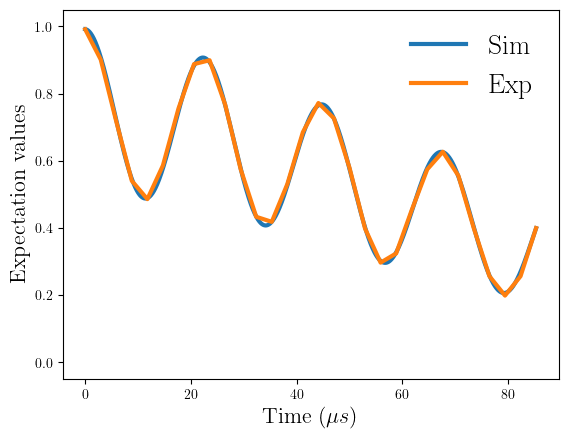

In [16]:
beta2 = 0.
J = 0.
eps = 0.0

# Learned parameters
beta1 = 0.5
xi = 0.613

spam = 0.008
gamma = 0.0047
lmbda = 0.0015
omega = np.pi*(1+eps)/dt

H = H_DS(beta1,beta2,xi,J,omega)
rho0 = rho_0p0
exp = 'DS+'
num_steps = 30*80
measure_steps = (num_steps//2+1)
tt = np.linspace(0,num_steps*dt,measure_steps)

result = qt.mesolve(H, rho0, tt, [np.sqrt(gamma) * IaI, np.sqrt(lmbda/2) * IZI], 
                                            [IXI], options=Options(store_final_state=True))

ps = (1+(1-2*spam)*result.expect[0])/2

fig, ax = plt.subplots()

ax.plot(tt, ps, lw=3, label='Sim') 
ax.plot(tt_exp, ps_exp[exp], lw=3, label='Exp') 

ax.set_xlabel('Time ($\mu s$)', size=16)
ax.set_ylabel('Expectation values', size=16) 
ax.legend(frameon=False, fontsize=20, bbox_to_anchor=(1,1))
ax.set_ylim(-0.05,1.05)
plt.show() 

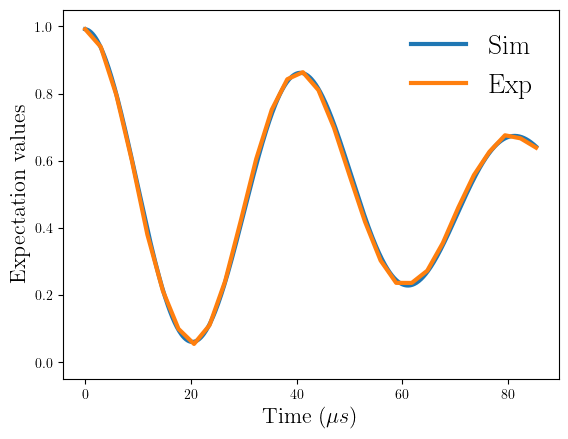

In [17]:
beta2 = 0.
J = -0.552

# Learned parameters
beta1 = 0.5
xi = 0.61
spam = 0.008
gamma = 0.0047
lmbda = 0.0015
nu = 0.0042
eps = 0.031
omega = np.pi*(1+eps)/dt

H = H_FE(beta1,beta2,xi,J,omega)
rho0 = rho_0p0
exp = 'FE+'
num_steps = 80*30
measure_steps = (num_steps//4+1)
tt = np.linspace(0,num_steps*dt,measure_steps)

result = qt.mesolve(H, rho0, tt, [np.sqrt(gamma) * IaI, np.sqrt(lmbda/2) * IZI], 
                                            [IXI], options=Options(store_final_state=True))

ps = (1+(1-2*spam)*result.expect[0])/2

fig, ax = plt.subplots()

ax.plot(tt, ps, lw=3, label='Sim') 
ax.plot(tt_exp, ps_exp[exp], lw=3, label='Exp') 

ax.set_xlabel('Time ($\mu s$)', size=16)
ax.set_ylabel('Expectation values', size=16) 
ax.legend(frameon=False, fontsize=20, bbox_to_anchor=(1,1))
ax.set_ylim(-0.05,1.05)
plt.show()

# All together now

In [18]:
ps_exp = {0:{'FE': np.array([0.9919, 0.9395, 0.7968, 0.6014, 0.3807, 0.2127, 0.1   , 0.0552,
                    0.1111, 0.2418, 0.4205, 0.6057, 0.7524, 0.8431, 0.864 , 0.8107,
                    0.6988, 0.5574, 0.4187, 0.3035, 0.237 , 0.2367, 0.2732, 0.3554,
                    0.4613, 0.5577, 0.6272, 0.6762, 0.6671, 0.6394]),
             'DD': np.array([0.9916, 0.9015, 0.7173, 0.5406, 0.4861, 0.5863, 0.7557, 0.8881,
                    0.8995, 0.7679, 0.5752, 0.4336, 0.4186, 0.5308, 0.6853, 0.7722,
                    0.7267, 0.5792, 0.3986, 0.2972, 0.3246, 0.4534, 0.5748, 0.6272,
                    0.5562, 0.3987, 0.2567, 0.1991, 0.2569, 0.4   ])},
          3:{'FE': np.array([0.9795, 0.9216, 0.815 , 0.6763, 0.5123, 0.371 , 0.2342, 0.1558,
                    0.1374, 0.1758, 0.2547, 0.3737, 0.5089, 0.6371, 0.7464, 0.8113,
                    0.8343, 0.8132, 0.7359, 0.6379, 0.5287, 0.4202, 0.3264, 0.2642,
                    0.2492, 0.266 , 0.3375, 0.406 , 0.4989, 0.5891]),
             'DD': np.array([0.9761, 0.725 , 0.3588, 0.351 , 0.5073, 0.4416, 0.2521, 0.3667,
                    0.7206, 0.8292, 0.5772, 0.3829, 0.448 , 0.5361, 0.3736, 0.2486,
                    0.426 , 0.7028, 0.6962, 0.498 , 0.4185, 0.5255, 0.5277, 0.3544,
                    0.293 , 0.4964, 0.6508, 0.6043, 0.4624, 0.4731])}
        }

In [19]:
# Learned parameters
params = {0:{'beta1':0.5,'J':-0.552,'xi':0.61,'spam':0.008,'gamma':0.0047,'lmbda':0.0015,'nu':0.00,'eps':0.031,'omega':np.pi*(1+eps)/dt},
          3:{'beta1':0.36*4.08,'J':-0.36*4.08,'xi':0.13*4.08,'spam':0.02,'gamma':0.011,'lmbda':0.004,'nu':0.00,'eps':0.031,'omega':np.pi*(1+eps)/dt}}

exp_vals = { 'FE':[IXI],
             'DD':[IXI]}

rho0s = {'FE':rho_0p0,
         'DD':rho_0p0}

Hs = {'FE': H_FE,
      'DD': H_DS}

labels = ['FE','DD']

In [20]:
ps_sims = {}
for qubit,params_q in params.items():
    ps_sims[qubit] = {}
    for idx,label in enumerate(labels):
        noise_ops = {'FE': [np.sqrt(params_q['gamma']) * IaI, np.sqrt(params_q['lmbda']/2) * IZI],
                     'DD': [np.sqrt(params_q['gamma']) * IaI, np.sqrt(params_q['lmbda']/2) * IZI]}
        result = qt.mesolve(Hs[label](params_q['beta1'],0,params_q['xi'],params_q['J'],params_q['omega']), 
                            rho0s[label], tt, noise_ops[label], exp_vals[label], options=Options(store_final_state=True, nsteps=5000))
        ps_sims[qubit][label] = (1+(1-2*params_q['spam'])*result.expect[0])/2

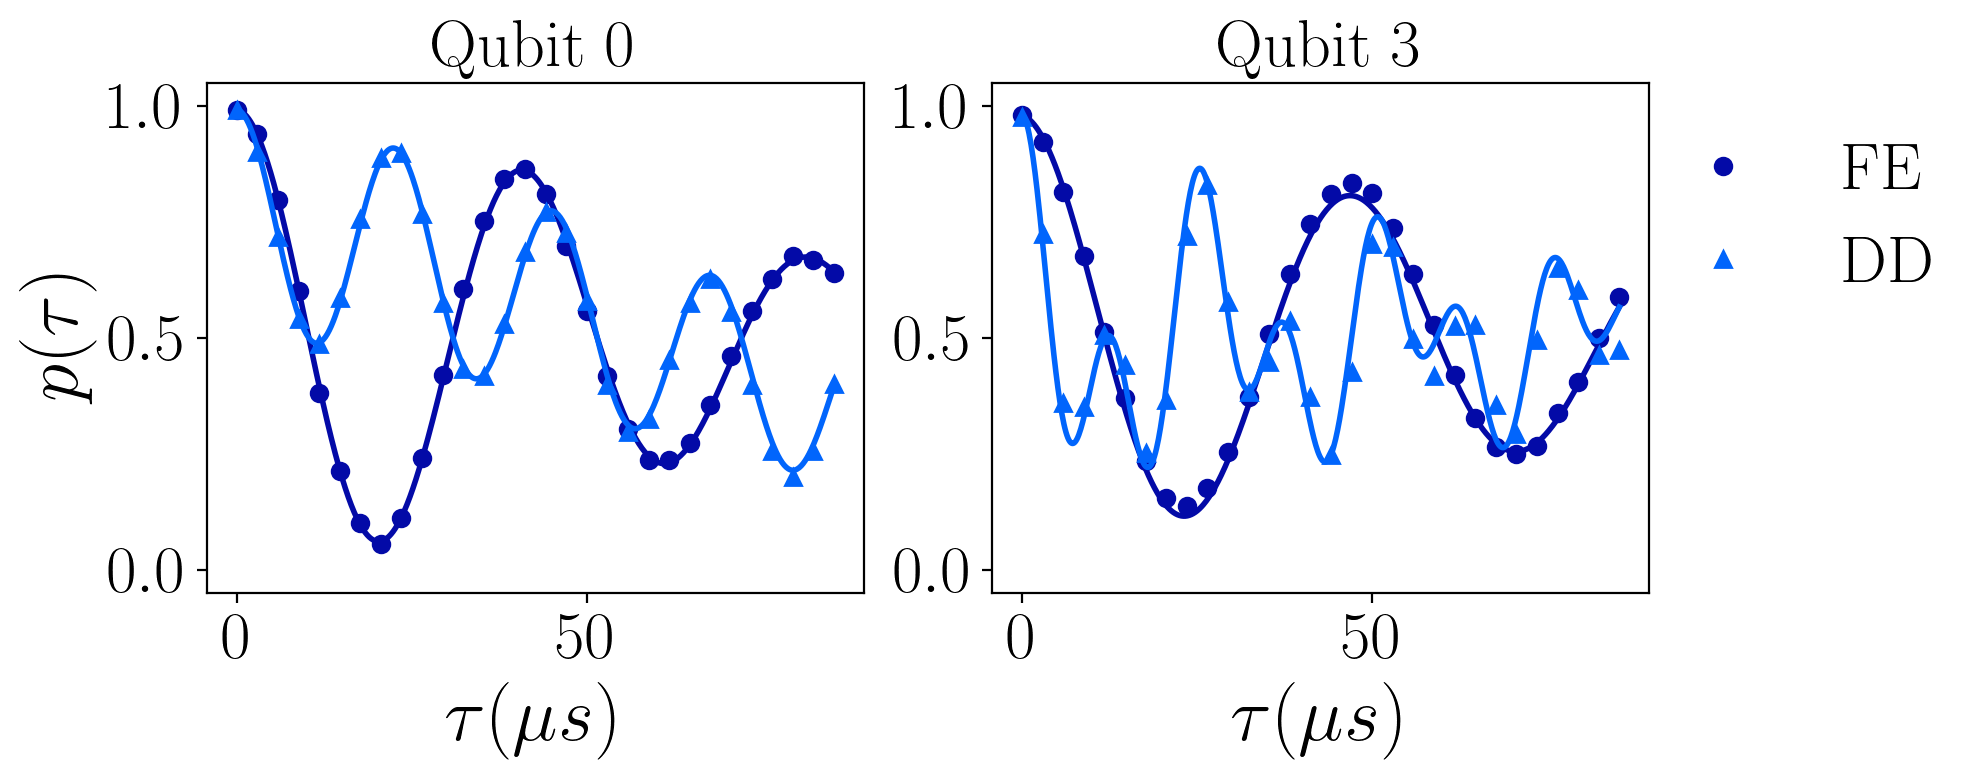

In [28]:
markers = ['o','^']

fig, axes = plt.subplots(1,2,dpi=200, figsize=(10,4))
for idx,(qubit,params_q) in enumerate(params.items()):
    ax = axes[idx]
    ax.set_title("Qubit %d"%qubit,size=24)
    for idx,label in enumerate(labels):
        ax.plot(tt, ps_sims[qubit][label], lw=2, color=colors_greg[idx+2])
        ax.plot(tt_exp, ps_exp[qubit][label], ls='', marker=markers[idx], label=label, color=colors_greg[idx+2])
    
    ax.set_xlabel(r'$\tau (\mu s)$', size=28)
    ax.set_ylim(-0.05,1.05)
    ax.tick_params(axis='both', labelsize=24)

axes[0].set_ylabel(r'$p(\tau)$', size=28) 
axes[1].legend(frameon=False, fontsize=24, bbox_to_anchor=(.92,1))
plt.tight_layout()
plt.savefig('figures/TLS_XT.pdf')
plt.show() 

In [248]:
params = {0:{'beta1':0.5,'J':-0.552,'xi':0.61,'spam':0.008,'gamma':0.0047,'lmbda':0.0015,'nu':0.00,'eps':0.031,'omega':np.pi*(1+eps)/dt},
          3:{'beta1':0.36*4.08,'J':-0.36*4.08,'xi':0.13*4.08,'spam':0.02,'gamma':0.011,'lmbda':0.004,'nu':0.00,'eps':0.031,'omega':np.pi*(1+eps)/dt}}

qubit = 3
params_q = params[qubit]

noise_ops = {'FE': [np.sqrt(params_q['gamma']) * IaI, np.sqrt(params_q['lmbda']/2) * IZI],
             'DD': [np.sqrt(params_q['gamma']) * IaI, np.sqrt(params_q['lmbda']/2) * IZI]}

ps_sims[qubit] = {}
for idx,label in enumerate(labels):
    result = qt.mesolve(Hs[label](params_q['beta1'],0,params_q['xi'],params_q['J'],params_q['omega']), 
                        rho0s[label], tt, noise_ops[label], exp_vals[label], options=Options(store_final_state=True, nsteps=5000))
    ps_sims[qubit][label] = (1+(1-2*params_q['spam'])*result.expect[0])/2

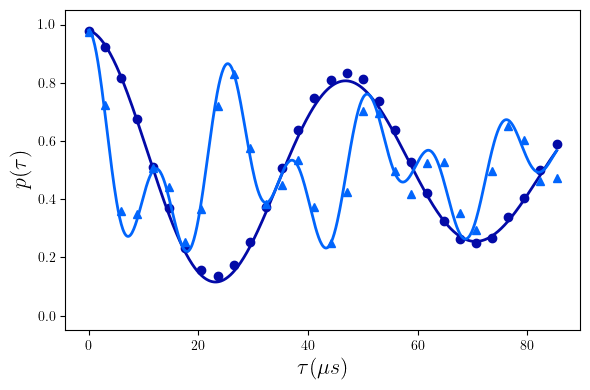

In [249]:
markers = ['o','^']

qubit = 3
fig, ax = plt.subplots(dpi=100, figsize=(6,4))
    # ax.set_title("Qubit %d",size=20)
for idx,label in enumerate(labels):
    ax.plot(tt, ps_sims[qubit][label], lw=2, color=colors_greg[idx+2])
    ax.plot(tt_exp, ps_exp[qubit][label], ls='', marker=markers[idx], label=label, color=colors_greg[idx+2])

ax.set_xlabel(r'$\tau (\mu s)$', size=16)
ax.set_ylim(-0.05,1.05)
    
ax.set_ylabel(r'$p(\tau)$', size=16) 
# ax.legend(frameon=False, fontsize=18, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show() 

In [218]:
a = params_q['gamma']/2+params_q['lmbda']
fit_fun = lambda t,f,xi: (1+(1-2*0.02)*np.exp(-a*t)*np.cos(f*t)*np.cos(xi*t))/2

[-5.95442069e-07  1.32906870e-01]
[0.36257137 0.12910712]


/home/yasuo/anaconda3/envs/mezze_venv/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


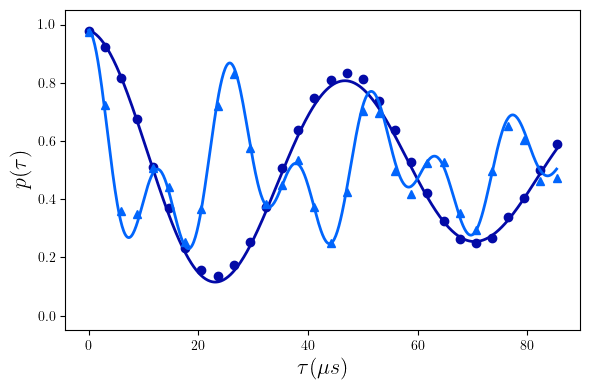

In [238]:
fig, ax = plt.subplots(dpi=100, figsize=(6,4))

label = 'FE'
idx = 0
params,_ = spopt.curve_fit(fit_fun,tt_exp,ps_exp[qubit][label],p0=(0.01,0.13))
print(params)
ax.plot(tt, fit_fun(tt,*params), lw=2, color=colors_greg[idx+2])
ax.plot(tt_exp, ps_exp[qubit][label], ls='', marker=markers[idx], label=label, color=colors_greg[idx+2])

label = 'DD'
idx = 1
params,_ = spopt.curve_fit(fit_fun,tt_exp,ps_exp[qubit][label],p0=(.4,0.13))
print(params)
ax.plot(tt, fit_fun(tt,*params), lw=2, color=colors_greg[idx+2])
ax.plot(tt_exp, ps_exp[qubit][label], ls='', marker=markers[idx], label=label, color=colors_greg[idx+2])

ax.set_xlabel(r'$\tau (\mu s)$', size=16)
ax.set_ylim(-0.05,1.05)
ax.set_ylabel(r'$p(\tau)$', size=16) 
plt.tight_layout()
plt.show() 